In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('../size/results.csv')
column_names = ['database', 'target', 'size', 'strategy','sampler','model','batch','seed']
for m in ['rf', 'gbt', 'sv', 'nn', 'gp', 'gp_ard', 'knn']:
    for metric in ['r2', 'mae', 'rmse', 'rel-rmse', 'pearson', 'spearman']:
        column_names.append(f'{m}-{metric}')
df.columns = column_names

In [4]:
df.head(10)

,database,target,size,strategy,sampler,model,batch,seed,rf-r2,rf-mae,...,gp_ard-rmse,gp_ard-rel-rmse,gp_ard-pearson,gp_ard-spearman,knn-r2,knn-mae,knn-rmse,knn-rel-rmse,knn-pearson,knn-spearman
0,polyomics,density,100,sf,cluster,none,none,2,0.70888,0.04691,...,0.06045,0.47819,0.87932,0.89911,0.68504,0.04971,0.07094,0.56121,0.84561,0.85733
1,polyomics,thermal_conductivity,100,al,none,gp_ard,topk,2,-0.06508,0.04048,...,0.06579,1.04820,0.05955,0.14611,-0.04600,0.04004,0.06420,1.02274,0.04262,0.14490
2,polyomics,density,100,sf,random,none,none,8,0.63896,0.05336,...,0.05628,0.44524,0.89570,0.91312,0.54925,0.06216,0.08487,0.67138,0.75797,0.76868
3,polyomics,thermal_conductivity,100,al,none,gp,cluster_margin,9,-0.03593,0.04037,...,0.06524,1.03940,0.12460,0.22202,-0.02183,0.03951,0.06345,1.01085,0.10243,0.25102
4,polyomics,thermal_conductivity,100,al,none,nn,topk,6,-0.18280,0.04705,...,0.07017,1.11789,0.07551,0.06554,-0.24200,0.04824,0.06995,1.11445,0.07303,0.11895
5,polyomics,thermal_conductivity,100,al,none,sv,cluster_margin,8,-0.27490,0.04595,...,0.06294,1.00266,0.01540,0.03918,-0.04271,0.04103,0.06410,1.02113,0.04005,0.05573
6,polyomics,thermal_conductivity,100,al,none,gp,topk,10,-0.19474,0.04716,...,0.06718,1.07034,0.04897,0.09733,-0.26913,0.05015,0.07071,1.12656,0.06884,0.08449
7,polyomics,thermal_conductivity,100,al,none,rf,topk,7,-0.20722,0.04354,...,0.06933,1.10457,0.11764,0.18052,-0.25737,0.04439,0.07038,1.12132,0.12030,0.25176
8,polyomics,thermal_conductivity,100,sf,random,none,none,8,-0.09494,0.04296,...,0.06729,1.07205,0.05863,0.14413,-0.08539,0.04313,0.06539,1.04182,0.05288,0.06997
9,polyomics,density,100,al,none,nn,topk,6,0.45485,0.07186,...,0.11867,0.93878,0.60689,0.60263,0.33896,0.07677,0.10278,0.81305,0.69753,0.66938


In [5]:
df.tail(10)

,database,target,size,strategy,sampler,model,batch,seed,rf-r2,rf-mae,...,gp_ard-rmse,gp_ard-rel-rmse,gp_ard-pearson,gp_ard-spearman,knn-r2,knn-mae,knn-rmse,knn-rel-rmse,knn-pearson,knn-spearman
8390,oqmd14,e_form,5000,al,none,nn,topk,9,0.80026,0.27867,...,0.48222,0.56478,0.82574,0.70607,0.76189,0.30119,0.41664,0.48796,0.87486,0.78480
8391,oqmd14,e_form,5000,al,none,knn,topk,9,0.81294,0.27392,...,0.96608,1.13146,0.42046,0.22389,0.76009,0.30689,0.41821,0.48981,0.87357,0.76597
8392,oqmd14,e_form,5000,al,none,nn,topk,3,0.80216,0.27859,...,0.49980,0.58536,0.81579,0.69663,0.76947,0.29247,0.40995,0.48013,0.87795,0.78264
8393,oqmd14,e_form,5000,al,none,gp,topk,9,0.78105,0.28891,...,0.48127,0.56365,0.82887,0.71794,0.75013,0.30800,0.42681,0.49987,0.87051,0.77664
8394,oqmd14,e_form,5000,al,none,gp_ard,topk,9,0.77651,0.28935,...,0.51548,0.60372,0.79976,0.69304,0.74486,0.30776,0.43128,0.50511,0.86449,0.77762
8395,oqmd14,e_form,5000,al,none,gp_ard,topk,10,0.78248,0.28508,...,0.53143,0.62240,0.78644,0.70046,0.73982,0.30728,0.43552,0.51008,0.86019,0.76588
8396,oqmd14,e_form,5000,al,none,gp_ard,topk,3,0.79906,0.27493,...,0.50638,0.59306,0.81162,0.69256,0.77818,0.28620,0.40214,0.47098,0.88283,0.80266
8397,oqmd14,e_form,5000,al,none,gp,topk,3,0.80576,0.27204,...,0.46590,0.54566,0.84621,0.72906,0.78752,0.28131,0.39358,0.46096,0.88751,0.79482
8398,oqmd14,e_form,5000,al,none,gp_ard,topk,8,0.78203,0.28175,...,0.48835,0.57195,0.82462,0.71466,0.73869,0.30849,0.43647,0.51118,0.86008,0.76865
8399,oqmd14,e_form,5000,al,none,nn,topk,1,0.80175,0.27817,...,0.50927,0.59645,0.80327,0.69350,0.75444,0.30500,0.42311,0.49554,0.86941,0.75924


In [6]:
# Determine top-performing dataset selection strategies, averaged across
# all tasks and proprety prediction architectures.
METRIC = 'spearman'
included_columns = [name for name in column_names if METRIC in name]
included_columns.insert(0, 'seed')
included_columns.insert(0, 'batch')
included_columns.insert(0, 'model')
included_columns.insert(0, 'sampler')
included_columns.insert(0, 'strategy')
included_columns.insert(0, 'size')
included_columns.insert(0, 'target')
included_columns.insert(0, 'database')
average_results = df[included_columns]
average_results.head(20)

average_results_long = average_results.melt(
    id_vars=['database', 'target', 'size', 'strategy', 'sampler', 'model', 'batch', 'seed'],
    value_vars=[name for name in column_names if METRIC in name],
    var_name='metric_full',
    value_name='metric_value'
)
average_results_long['predictor'] = average_results_long['metric_full'].str.replace(f'-{METRIC}$', '', regex=True)
average_results_long.head(10)

norm_factors = average_results_long.groupby(['database', 'target', 'size', 'strategy', 'sampler', 'model', 'batch', 'predictor'])['metric_value'].mean().reset_index()
norm_factors = norm_factors.groupby(['database', 'target', 'size'])['metric_value'].max().reset_index()
norm_factors = norm_factors.set_index(['database', 'target', 'size'])['metric_value'].to_dict()
keys = list(zip(average_results_long['database'], average_results_long['target'], average_results_long['size']))
average_results_long['norm_value'] = pd.Series(keys).map(norm_factors)
average_results_long['score_norm'] = average_results_long['metric_value'] / average_results_long['norm_value']
average_results_long.head(10)

average_results_long = average_results_long[['database', 'target', 'size', 'strategy', 'sampler', 'model', 'batch', 'predictor', 'score_norm']]
average_results_grouped = average_results_long.groupby(['size', 'strategy', 'sampler', 'model', 'batch'])
average_results_agg = average_results_grouped['score_norm'].agg(['mean', 'sem']).reset_index()
average_results_agg = average_results_agg.sort_values(by='mean', ascending=False)
average_results_agg.head(100)

,size,strategy,sampler,model,batch,mean,sem
48,5000,al,none,nn,cluster_margin,0.962054,0.001544
54,5000,sf,cluster,none,none,0.959060,0.001804
55,5000,sf,random,none,none,0.956246,0.001526
50,5000,al,none,rf,cluster_margin,0.944334,0.001971
34,1000,al,none,nn,cluster_margin,0.940359,0.002960
41,1000,sf,random,none,none,0.937575,0.002736
46,5000,al,none,knn,cluster_margin,0.937163,0.002352
40,1000,sf,cluster,none,none,0.934806,0.003110
20,500,al,none,nn,cluster_margin,0.932839,0.003673
52,5000,al,none,sv,cluster_margin,0.931505,0.002820


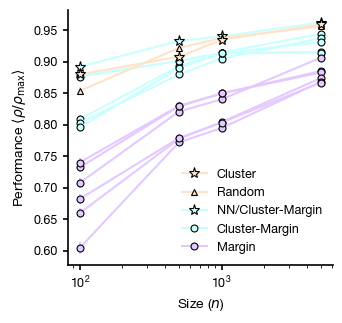

In [9]:
# Process results for plotting.
plot_dict = {}
for _, row in average_results_agg.iterrows():
    tup = (row['strategy'], row['sampler'], row['model'], row['batch'])
    if tup not in plot_dict.keys():
        plot_dict[tup] = {
            100: 0,
            500: 0,
            1000: 0,
            5000: 0
        }
    plot_dict[tup][row['size']] = [row['mean'], row['sem']]

# Plot performances of algorithms across dataset sizes.
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 9
plt.rcParams['axes.linewidth'] = 1.2
fig, ax = plt.subplots(1,1,figsize=(3.5,3.3))

algo_colors = {
    'cluster': '#FFE3C9',
    'random': '#FFE3C9',
    'topk': "#E3C9FF",
    'cluster_margin': "#C9FFFE",
}

for algo, data in plot_dict.items():
    x = list(data.keys())
    y = [item[0] for item in data.values()]
    y_err = [item[1] for item in data.values()]

    if algo[1] == 'cluster':
        ax.errorbar(x, y, yerr=y_err, color=algo_colors['cluster'], marker='*', ms=8, mec='black', mew=0.8, zorder=10)
    elif algo[1] == 'random':
        ax.errorbar(x, y, yerr=y_err, color=algo_colors['random'], marker='^', ms=5, mec='black', mew=0.8, zorder=9)
    elif algo[3] == 'cluster_margin' and algo[2] == 'nn':
        ax.errorbar(x, y, yerr=y_err, color=algo_colors['cluster_margin'], marker='*', ms=8, mec='black', mew=0.8, zorder=8)
    elif algo[3] == 'topk':
        ax.errorbar(x, y, yerr=y_err, color=algo_colors['topk'], marker='o', ms=5, mec='black', mew=0.8, zorder=7)
    elif algo[3] == 'cluster_margin':
        ax.errorbar(x, y, yerr=y_err, color=algo_colors['cluster_margin'], marker='o', ms=5, mec='black', mew=0.8, zorder=7)

ax.set_xscale('log')
ax.set_xlabel(r'Size ($\it{n}$)', fontsize=10)
ax.set_ylabel(r'Performance $\langle\rho/\rho_\text{max}\rangle$', fontsize=10)
ax.tick_params(width=1.2)
ax.spines[['top', 'right']].set_visible(False)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D(
        [0], [0],
        marker='*',
        color=algo_colors['cluster'],
        label='Cluster',
        markerfacecolor=algo_colors['cluster'],
        markeredgecolor='black',
        markersize=8,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='^',
        color=algo_colors['random'],
        label='Random',
        markerfacecolor=algo_colors['random'],
        markeredgecolor='black',
        markersize=5,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='*',
        color=algo_colors['cluster_margin'],
        label='NN/Cluster-Margin',
        markerfacecolor=algo_colors['cluster_margin'],
        markeredgecolor='black',
        markersize=8,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color=algo_colors['cluster_margin'],
        label='Cluster-Margin',
        markerfacecolor=algo_colors['cluster_margin'],
        markeredgecolor='black',
        markersize=5,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color=algo_colors['topk'],
        label='Margin',
        markerfacecolor=algo_colors['topk'],
        markeredgecolor='black',
        markersize=5,
        mew=0.8
    ),
]

ax.legend(handles=legend_elements, frameon=False, loc='lower right')
plt.tight_layout()
plt.savefig('./figures/size_sensitivity.pdf', dpi=500, transparent=True)
plt.show()